In [1]:
import tensorflow as tf
from tensorflow import keras
from keras.models import load_model
from sklearn.model_selection import train_test_split
from keras.layers import Input, Dense, Flatten, Conv2D, BatchNormalization, MaxPooling2D, Dropout
import matplotlib.pyplot as plt
import os
import pickle
from glob import glob
from tqdm import tqdm
from PIL import Image
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd

In [2]:
FOLDER_IMAGES = './datasets/dmd/binary_labels'
INPUT_SHAPE = (180, 180, 3)
BATCH_SIZE = 32
IMG_SIZE = (180, 180)
VAL_SPLIT = 0.2
MODEL_SAVE_FOLDER = './models/cnn/cnn_simple/'

In [3]:
X = []
Y = []
for i in tqdm(glob(FOLDER_IMAGES + '/awake/*')):
    temp = np.array(Image.open(i).resize(IMG_SIZE))
    X.append(temp)
    Y.append(1)

for i in tqdm(glob(FOLDER_IMAGES + '/drowsy/*')):
    temp = np.array(Image.open(i).resize(IMG_SIZE))
    X.append(temp)
    Y.append(0)

X = np.array(X)
X = X / 255.0
Y = np.array(Y)
X = np.expand_dims(X, -1)

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.33)

100%|██████████| 4742/4742 [00:34<00:00, 136.16it/s]


In [15]:
if os.path.exists(MODEL_SAVE_FOLDER):
    model = keras.models.load_model(MODEL_SAVE_FOLDER + 'best.h5')
else:
    model = keras.models.Sequential([
        Input(shape=INPUT_SHAPE),

        Conv2D(filters=32, kernel_size=5, strides=1, activation='relu'),
        Conv2D(filters=32, kernel_size=5, strides=1, activation='relu', use_bias=False),
        BatchNormalization(),
        MaxPooling2D(strides=2),
        Dropout(0.3),

        Conv2D(filters=64, kernel_size=3, strides=1, activation='relu'),
        Conv2D(filters=64, kernel_size=3, strides=1, activation='relu', use_bias=False),
        BatchNormalization(),
        MaxPooling2D(strides=2),
        Dropout(0.3),

        Flatten(),
        Dense(units=256, activation='relu', use_bias=False),
        BatchNormalization(),

        Dense(units=128, use_bias=False, activation='relu'),

        Dense(units=84, use_bias=False, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(units=1, activation='sigmoid')
    ])

    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3)

    model_checkpoint = keras.callbacks.ModelCheckpoint(
        filepath=MODEL_SAVE_FOLDER + 'best.h5',
        monitor='val_loss',
        mode='min',
        save_best_only=True,
        verbose=1
    )

    model.fit(
        x_train,
        y_train,
        validation_split=0.2,
        epochs=30,
        batch_size=32,
        callbacks=[early_stop, model_checkpoint]
    )

    with open(MODEL_SAVE_FOLDER + 'model_history.pkl', 'wb') as file:
        pickle.dump(model.history, file)

    with open(MODEL_SAVE_FOLDER + 'model_history.pkl', 'rb') as file:
        history = pickle.load(file)

Epoch 1/30
175/176 [============================>.] - ETA: 0s - loss: 0.5294 - accuracy: 0.7450
Epoch 1: val_loss improved from inf to 1.65251, saving model to ./models/cnn/cnn_simple\best.h5
176/176 [==============================] - 13s 70ms/step - loss: 0.5306 - accuracy: 0.7449 - val_loss: 1.6525 - val_accuracy: 0.4558
Epoch 2/30
175/176 [============================>.] - ETA: 0s - loss: 0.3971 - accuracy: 0.8180
Epoch 2: val_loss improved from 1.65251 to 1.03561, saving model to ./models/cnn/cnn_simple\best.h5
176/176 [==============================] - 12s 67ms/step - loss: 0.3972 - accuracy: 0.8180 - val_loss: 1.0356 - val_accuracy: 0.5548
Epoch 3/30
175/176 [============================>.] - ETA: 0s - loss: 0.2579 - accuracy: 0.8966
Epoch 3: val_loss improved from 1.03561 to 0.42059, saving model to ./models/cnn/cnn_simple\best.h5
176/176 [==============================] - 12s 67ms/step - loss: 0.2575 - accuracy: 0.8969 - val_loss: 0.4206 - val_accuracy: 0.7628
Epoch 4/30
175/17

INFO:tensorflow:Assets written to: ram://3ccc5cb4-95f3-4f82-a95b-ea158ed06099/assets


INFO:tensorflow:Assets written to: ram://3ccc5cb4-95f3-4f82-a95b-ea158ed06099/assets


FileNotFoundError: Unsuccessful TensorSliceReader constructor: Failed to find any matching files for ram://ad67c66e-78b4-4d7a-aa38-cbde8ab9686a/variables/variables
 You may be trying to load on a different device from the computational device. Consider setting the `experimental_io_device` option in `tf.saved_model.LoadOptions` to the io_device such as '/job:localhost'.

In [16]:
best_model = load_model(MODEL_SAVE_FOLDER + 'best.h5')
best_model.evaluate(x_test, y_test)

109/109 [==============================] - 3s 27ms/step - loss: 0.1665 - accuracy: 0.9398


[0.16645878553390503, 0.9398496150970459]

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open(MODEL_SAVE_FOLDER + 'model.tflite', 'wb') as f:
    f.write(tflite_model)

In [17]:
acc = history['accuracy']
val_acc = history['val_accuracy']
loss = history['loss']
val_loss = history['val_loss']
epochs = range(len(acc))

plt.plot(epochs, acc, label='Entrenamiento acc', color='green')
plt.plot(epochs, val_acc, label='Validación acc', color='blue')
plt.title('Accuracy - exactitud de entrenamiento y validación')
plt.legend()
plt.figure()

plt.plot(epochs, loss, color='green', label='Entrenamiento loss')
plt.plot(epochs, val_loss, color='blue', label='Validación loss')
plt.title('Loss - función objetivo en entrenamiento y prueba')
plt.legend()

plt.show()

TypeError: 'History' object is not subscriptable

In [19]:
for i in x_test[0:5]:
    result = best_model.predict(np.expand_dims(i, 0))
    print(result)
    plt.imshow(i)
    plt.show()

    if result > 0.5:
        print('Awake')
    else:
        print("Drowsy")

1/1 [==============================] - 0s 13ms/step
[[0.9967924]]
Awake
1/1 [==============================] - 0s 15ms/step
[[0.00546528]]
Drowsy
1/1 [==============================] - 0s 13ms/step
[[0.9989812]]
Awake
1/1 [==============================] - 0s 15ms/step
[[0.0383702]]
Drowsy
1/1 [==============================] - 0s 16ms/step
[[0.9985935]]
Awake


109/109 [==============================] - 3s 25ms/step


Text(0.5, 25.722222222222214, 'Actual')

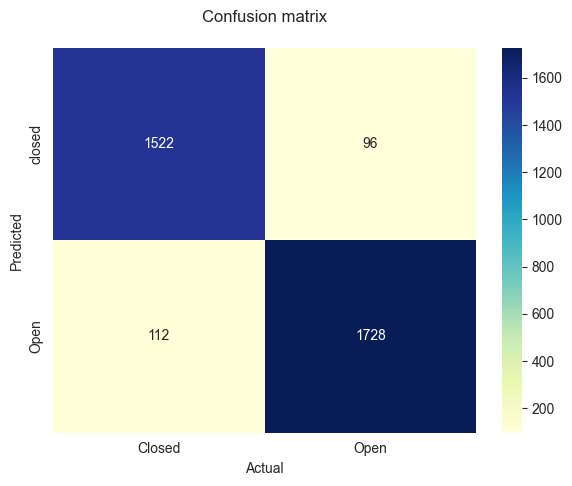

In [20]:
plt.figure(figsize=(15, 5))

preds = best_model.predict(x_test)
preds = (preds >= 0.5).astype(np.int32)
cm = confusion_matrix(y_test, preds)
df_cm = pd.DataFrame(cm, index=['closed', 'Open'], columns=['Closed', 'Open'])
plt.subplot(121)
plt.title("Confusion matrix\n")
sns.heatmap(df_cm, annot=True, fmt="d", cmap="YlGnBu")
plt.ylabel("Predicted")
plt.xlabel("Actual")